# Changes 
## To improve Performance and Generation from pixelcnn_md.ipynb

Recommended by Claude Haiku 4.5.

Key changes:

Fewer epochs (5 instead of 10)
Larger batch size (256 for faster processing)
Smaller model (fewer hierarchies and filters)
Early stopping to halt if loss plateaus

# 👾 PixelCNN using Tensorflow distributions

In this notebook, we'll walk through the steps required to train your own PixelCNN on the fashion MNIST dataset using Tensorflow distributions

In [33]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()


In [34]:
# %load_ext autoreload
# %autoreload 2
import numpy as np

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, callbacks
import tensorflow_probability as tfp

# from notebooks.utils import display

In [35]:
import os
os.makedirs("./output", exist_ok=True)
os.makedirs("./logs", exist_ok=True)

## 0. Parameters <a name="parameters"></a>

For improved generated data quality, **50 epochs is better** than batch size 256.

Here's why:

| Factor | Impact |
|--------|--------|
| **More epochs (50)** | Model sees data multiple times, learns patterns better, generates more coherent images |
| **Larger batch (256)** | Faster training but less gradient updates per epoch, may miss fine details |


**Why this works:**
- **50 epochs** = More training time for pattern learning
- **Batch 128** = Reasonable speed + better gradient signal than 256
- **Early stopping** = Prevents overfitting if model converges early

**DISPLAY_AFTER_EPOCH Tradeoffs:**

| Value | Frequency | Speed | Monitoring |
|-------|-----------|-------|-----------|
| `2` | Every 2 epochs | Slower | Detailed progress |
| `5` | Every 5 epochs | Faster | Balanced |
| `10` | Every 10 epochs | Fastest | Less feedback |

**LEARNING RATE**

Not yet a hyperparameter.

Consider these adjustments based on training behavior:

**Lower learning rate if:**
- Loss is unstable or oscillating wildly
- Model overshoots optimal weights

**Keep current (0.001) if:**
- Loss decreases smoothly and steadily
- Training converges without diverging

A **learning rate of 0.0005** offers a good balance:
- Faster than 0.0001 (won't take forever)
- More stable than 0.001 (better convergence)
- Better for smaller models with limited hierarchies

Monitor the loss curve during training. If it plateaus early or shows erratic spikes, lower it further to 0.0002.

In [36]:
IMAGE_SIZE = 32
N_COMPONENTS = 5
EPOCHS = 50  # Prioritize this for quality
# BATCH_SIZE = 64  # Smaller batch for better gradient updates
BATCH_SIZE = 128  # Balance speed and gradient updates
DISPLAY_AFTER_EPOCH = 10 # Display samples every 10 epochs as impacts performance and quality
EARLY_STOP_PATIENCE = 5  # More patient (50 epochs total). 2 too short, 5 is a good balance between training time and quality. 10 is too long and may overfit.
LEARNING_RATE = 0.0001  # 0.001 is default learning rate for Adam optimizer


## 1. Prepare the data <a name="prepare"></a>

In [37]:
# Load the data
(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

In [38]:
# Preprocess the data


def preprocess(imgs):
    imgs = np.expand_dims(imgs, -1)
    imgs = tf.image.resize(imgs, (IMAGE_SIZE, IMAGE_SIZE)).numpy()
    return imgs


input_data = preprocess(x_train)

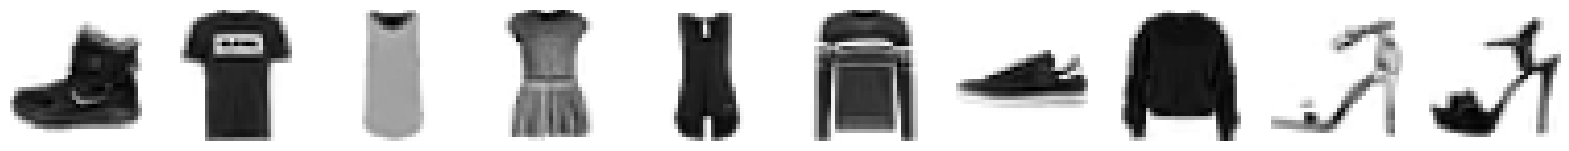

In [39]:
# Show some items of clothing from the training set
display(input_data)

## 2. Build the PixelCNN <a name="build"></a>

In [40]:
# Define a Pixel CNN network
dist = tfp.distributions.PixelCNN(
    image_shape=(IMAGE_SIZE, IMAGE_SIZE, 1),
    num_resnet=1,  # Keep small
    num_hierarchies=1,  # Reduced from 2
    num_filters=16,  # Reduced from 32
    num_logistic_mix=N_COMPONENTS,
    dropout_p=0.3,
)

# Define the model input
# image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

# # Define the log likelihood for the loss fn
# log_prob = dist.log_prob(image_input)

# Define the model input
image_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1), dtype=tf.float32)

# Wrap log_prob in a Keras layer
log_prob = layers.Lambda(lambda x: dist.log_prob(x))(image_input)

# Define the model
pixelcnn = models.Model(inputs=image_input, outputs=log_prob)
# there were issues with using the log_prob directly as a loss function, so added it as a loss function to the model via compile step
# pixelcnn.add_loss(-tf.reduce_mean(log_prob))

## 3. Train the PixelCNN <a name="train"></a>

In [41]:
# Compile and train the model
# pixelcnn.compile(
#     optimizer=optimizers.Adam(0.001),
# )

# 3. Define a custom loss function for .compile()
def negative_log_likelihood(y_true, y_pred):
    # y_pred is the log_prob output from the model
    # y_true is passed by Keras fit(), but we only minimize the negative log_prob
    return -tf.reduce_mean(y_pred)

# 4. Compile without add_loss
pixelcnn.compile(
    # optimizer='adam',
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss=negative_log_likelihood
)

In [42]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def generate(self):
        return dist.sample(self.num_img).numpy()

    # def on_epoch_end(self, epoch, logs=None):
    #     generated_images = self.generate()
    #     display(
    #         generated_images,
    #         n=self.num_img,
    #         save_to="./output/generated_img_%03d.png" % (epoch),
    #     )

    def on_epoch_end(self, epoch, logs=None):
        """Display generated images at the end of every nth epoch.
        
        @see https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/Callback#on_epoch_end
        """
        if epoch % DISPLAY_AFTER_EPOCH == 0:
            generated_images = self.generate()
            display(
                generated_images,
                n=self.num_img,
                save_to="./output/generated_img_%03d.png" % (epoch),
            )

img_generator_callback = ImageGenerator(num_img=2)

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")



Saved to ./output/generated_img_000.png


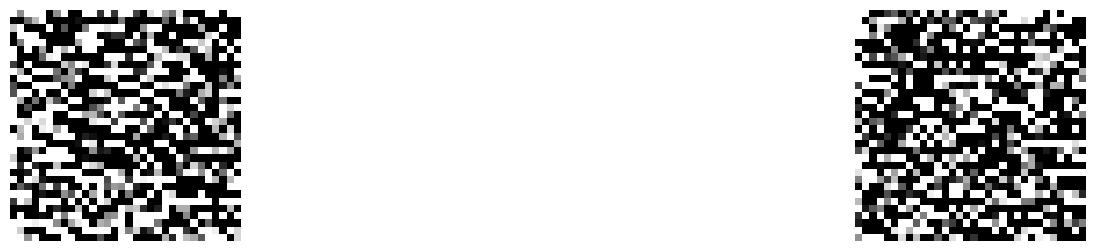

Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.


In [43]:
# from Claude Haiky 4.5
# The issue is that fit() expects (X, y) pairs, but your model outputs log_prob which has incompatible shapes with the default target format. You need to provide dummy targets or use a custom training loop.
# The negative_log_likelihood loss function ignores y_true and only minimizes -tf.reduce_mean(y_pred), so the dummy targets are just placeholders for Keras' API.

# Create dummy targets (not actually used, loss only depends on y_pred)
dummy_targets = np.zeros(len(input_data))

# Add early stopping
# Epoch 1: loss = 2.5  ✓ (best)
# Epoch 2: loss = 2.3  ✓ (best)
# Epoch 3: loss = 2.4  ✗ (no improvement, patience=1)
# Epoch 4: loss = 2.45 ✗ (no improvement, patience=2)
# → STOP. Restore weights from Epoch 2
early_stop = callbacks.EarlyStopping(
    monitor='loss',            # Watch this metric
    # patience=2,              # Stop if no improvement for 2 epochs (5 epochs total)
    patience=EARLY_STOP_PATIENCE,                # More patient (50 epochs total)
    restore_best_weights=True, # Revert to best weights
    verbose=1                  # Print when stopping
)

# pixelcnn.fit(
#     input_data,
#     dummy_targets,
#     batch_size=BATCH_SIZE,
#     epochs=EPOCHS,
#     verbose=True,
#     callbacks=[tensorboard_callback, img_generator_callback, early_stop],
# )

# Capture and plot the loss curve
history = pixelcnn.fit(
    input_data,
    dummy_targets,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback, img_generator_callback, early_stop],
    verbose=0,  # silent to avoid duplicate output
)

## 4. Generate images <a name="generate"></a>

In [44]:
generated_images = img_generator_callback.generate()

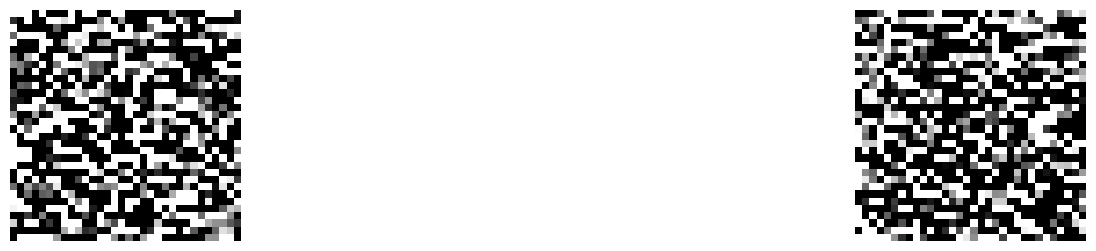

In [45]:
display(generated_images, n=img_generator_callback.num_img)

# Loss Table

In [46]:
history.history['loss'],

([4404.0703125,
  4404.0703125,
  4404.06982421875,
  4404.068359375,
  4404.07080078125,
  4404.0703125,
  4404.0693359375,
  4404.06884765625,
  4404.0703125],)

In [47]:
import pandas as pd

# Create a DataFrame from the loss history
loss_df = pd.DataFrame({
    'Epoch': range(len(history.history['loss'])),
    'Loss': history.history['loss']
})

# Print the table
print(loss_df.to_string(index=False))

# Or for a prettier table with formatting:
print("\n" + "="*40)
print(f"{'Epoch':<10} {'Loss':<20}")
print("="*40)
for epoch, loss in enumerate(history.history['loss']):
    print(f"{epoch:<10} {loss:<20.6f}")
print("="*40)

 Epoch        Loss
     0 4404.070312
     1 4404.070312
     2 4404.069824
     3 4404.068359
     4 4404.070801
     5 4404.070312
     6 4404.069336
     7 4404.068848
     8 4404.070312

Epoch      Loss                
0          4404.070312         
1          4404.070312         
2          4404.069824         
3          4404.068359         
4          4404.070801         
5          4404.070312         
6          4404.069336         
7          4404.068848         
8          4404.070312         


# Plot

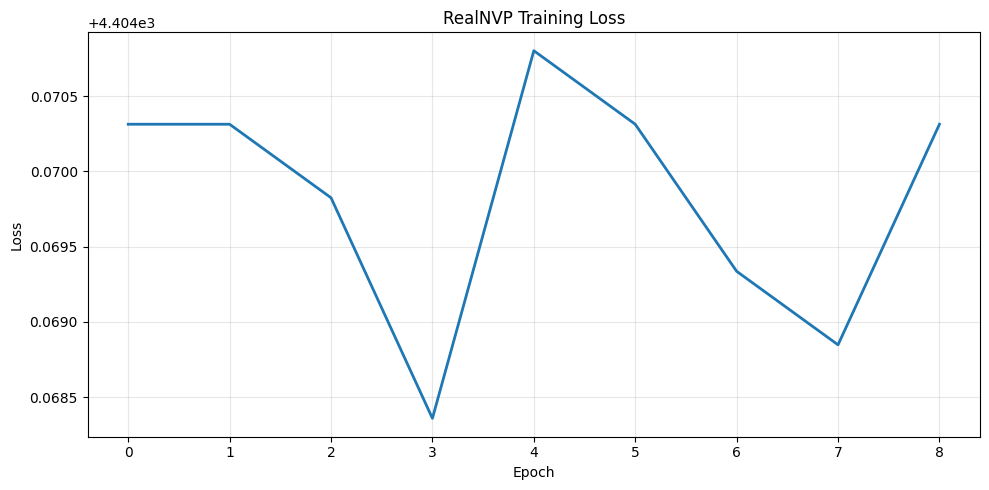

In [48]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RealNVP Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()